In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import sys
import localSettings as ls
import math
print(ls.main_path)
import load_data_run123
import plotter_alex
import importlib
importlib.reload(plotter_alex)
import uproot
import matplotlib.pylab as pylab
import numpy as np
import math
from sklearn.model_selection import train_test_split
import pickle
import xgboost as xgb
import nue_booster 
importlib.reload(nue_booster)
import awkward
from matplotlib import gridspec
from collections import defaultdict
import ROOT
from ROOT import TFile
from ROOT import TCanvas, TFile, TProfile, TNtuple, TH1F, TH2F
from ROOT import gROOT, gBenchmark, gRandom, gSystem
import csv

/home/alex/NuMI/PELEE/
Welcome to JupyROOT 6.24/02


In [2]:
import NuMIGeoWeights
import importlib
importlib.reload(NuMIGeoWeights)
numiBeamlineGeoWeights = NuMIGeoWeights.NuMIGeoWeights()

In [3]:
params = {
    'axes.labelsize': 'x-large',
    'axes.titlesize': 'x-large',
    'xtick.labelsize': 'x-large',
    'ytick.labelsize': 'x-large'
}
pylab.rcParams.update(params)

In [4]:
isRun3 = True

#to use both Run1 and Run3
isCombined = True

ending = "Mar25"

In [5]:
###########################################################

In [5]:
# Name of the TTree in the PeLEE Ntuples
tree = "NeutrinoSelectionFilter"

#full sample, re-weighted flux
if isRun3 == False and isCombined == False:
    NU   = '/numi_run1_nu_overlay_fhc_reweightedPPFX'    +ls.APPEND #newTune
elif isRun3 == True  and isCombined == False:
    NU   = '/numi_nu_pelee_ntuples_run3_rhc_g4.10.4_full'    +ls.APPEND 

#actually fetch datasets
if isCombined == False:
    numu_mc  = uproot.open(ls.ntuple_path+NU+".root")[ls.fold][tree]


# Define a list that contains the data sets
if isCombined == False:
    uproot_v = [numu_mc]

numu_variables = [
        "nu_pdg", "slpdg", "backtracked_pdg",
        "category", "ccnc", "swtrig_pre",
        "run","sub","evt",
        "CosmicIP","CosmicDirAll3D","CosmicIPAll3D",
        "contained_fraction",
        "trk_llr_pid_score_v",
        "_opfilter_pe_beam", "_opfilter_pe_veto",
        "reco_nu_vtx_sce_x","reco_nu_vtx_sce_y","reco_nu_vtx_sce_z",
        "nmuon", "n_showers_contained", "shr_tkfit_dedx_Y", "tksh_distance",
        "shr_energy_tot_cali", "trk_energy_tot",
        "nproton", "mc_pdg", "slnunhits", "slnhits", "true_e_visible",
        "npi0","npion","pion_e","muon_e","pi0truth_elec_etot",
        "pi0_e", "evnunhits", "nslice", "interaction",
        "slclustfrac", "reco_nu_vtx_x", "reco_nu_vtx_y", "reco_nu_vtx_z",
        "topological_score", "elec_e", "proton_e",
        "isVtxInFiducial", "trk_sce_end_x_v", "trk_sce_end_y_v", "trk_sce_end_z_v", "trk_sce_start_x_v",
        "trk_theta", "trk_phi", "trk_energy_muon", "trk_range_muon_mom_v", "trk_mcs_muon_mom_v"
    ]


# These are examples of variables present in MC samples only
numu_varMC = ["nu_e", "true_pt","true_pt_visible","true_p","true_p_visible","true_nu_vtx_t","true_nu_vtx_x","true_nu_vtx_y","true_nu_vtx_z","true_nu_vtx_sce_x","true_nu_vtx_sce_y","true_nu_vtx_sce_z\
","true_nu_px","true_nu_py","true_nu_pz", "theta", "mc_pdg", "mc_px", "mc_py", "mc_pz"]


#make the list unique (sometimes you repeat the variable name in the list, this takes care of that)
numu_variables = list(set(numu_variables))
print(numu_variables)



# These weights are needed to correctly calculate the CV for the MC    
WEIGHTS     = ["weightSpline","weightTune","weightSplineTimesTune","ppfx_cv"]
# These weights are needed to calculate the Flux, GENIE and Geant4 Systematics. 
# For NuMI weightsFlux should always be 1 (cause that's relevant for BNB).
SYSTEMATICS = ['weightsFlux','weightsGenie','weightsReint'] 
PPFX        = ['weightsPPFX'] 



WEIGHTSLEE = ["weightSpline","weightTune","weightSplineTimesTune", "leeweight"]
MCFVARS    = ["mcf_nu_e","mcf_lep_e","mcf_actvol","mcf_nmm","mcf_nmp","mcf_nem","mcf_nep","mcf_np0","mcf_npp",
              "mcf_npm","mcf_mcshr_elec_etot","mcf_pass_ccpi0","mcf_pass_ncpi0",
              "mcf_pass_ccnopi","mcf_pass_ncnopi","mcf_pass_cccpi","mcf_pass_nccpi"]


['reco_nu_vtx_sce_z', 'proton_e', 'CosmicIP', 'contained_fraction', 'npi0', 'trk_sce_end_y_v', 'nmuon', '_opfilter_pe_beam', 'trk_sce_end_x_v', 'reco_nu_vtx_sce_x', 'nproton', 'pi0truth_elec_etot', 'slnhits', 'slclustfrac', 'CosmicIPAll3D', 'trk_energy_muon', 'tksh_distance', 'npion', 'backtracked_pdg', 'nslice', 'slpdg', 'reco_nu_vtx_z', 'elec_e', 'trk_llr_pid_score_v', 'isVtxInFiducial', 'swtrig_pre', 'sub', 'topological_score', 'n_showers_contained', 'trk_sce_end_z_v', 'run', 'reco_nu_vtx_y', 'true_e_visible', 'interaction', 'trk_mcs_muon_mom_v', 'mc_pdg', 'trk_sce_start_x_v', 'evt', 'shr_energy_tot_cali', 'ccnc', 'trk_energy_tot', 'pion_e', 'trk_range_muon_mom_v', 'nu_pdg', 'reco_nu_vtx_sce_y', 'evnunhits', 'category', 'shr_tkfit_dedx_Y', 'CosmicDirAll3D', '_opfilter_pe_veto', 'reco_nu_vtx_x', 'muon_e', 'trk_theta', 'slnunhits', 'trk_phi', 'pi0_e']


In [6]:

import time
s = time.time()

import pandas as pandas

mc_var   = numu_variables + WEIGHTS + MCFVARS + SYSTEMATICS + PPFX + numu_varMC
var_v    = [mc_var] 


if isCombined == False:
    uproot_v = [numu_mc]
    for ii, CV in enumerate(uproot_v):
        CVDF  = CV.pandas.df(var_v[ii], flatten=False)
        print("clearing")
        load_data_run123.process_uproot_numu(CV,CVDF)
        if ii == 0:
            numu_mc = CVDF     

s2 = time.time()

print("runtime = ", s2-s)

clearing
trk_llr_pid_v  [[] [-3.4028235e+38 -0.53329843 -0.37919396 -0.16951479] [0.8026565 0.122559376] ... [] [] [0.9814954 0.88408315 0.2547488]]
trk_score_v  [[] [-1.0 0.8406699 0.89783436 0.8321769] [0.91174966 0.013312283] ... [] [] [1.0 0.0007528009 0.027561903]]


/home/alex/miniconda3/envs/vintageXgboostVintageUprootEnv/lib/python3.8/site-packages/awkward/array/jagged.py:1043: RuntimeWarning: overflow encountered in power
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/alex/miniconda3/envs/vintageXgboostVintageUprootEnv/lib/python3.8/site-packages/awkward/array/jagged.py:1043: RuntimeWarning: overflow encountered in true_divide
  result = getattr(ufunc, method)(*inputs, **kwargs)


updated proton mask test
runtime =  811.8330683708191


# Weights

In [7]:
df_v = [numu_mc]
for i,df in enumerate(df_v):
    df[ 'currentweightsafe' ] = df['weightSplineTimesTune']
    df[ 'currentweight' ] = df['weightSplineTimesTune']

In [8]:

s = time.time()

df_v = [numu_mc]
for i,df in enumerate(df_v):
    df.loc[ df['weightTune'] <= 0, 'weightTune' ] = 1.
    df.loc[ df['weightTune'] == np.inf, 'weightTune' ] = 1.
    df.loc[ df['weightTune'] > 100, 'weightTune' ] = 1.
    df.loc[ np.isnan(df['weightTune']) == True, 'weightTune' ] = 1.    
    
    df.loc[ df['weightSplineTimesTune'] <= 0, 'weightSplineTimesTune' ] = 1.
    df.loc[ df['weightSplineTimesTune'] == np.inf, 'weightSplineTimesTune' ] = 1.
    df.loc[ df['weightSplineTimesTune'] > 100, 'weightSplineTimesTune' ] = 1.
    df.loc[ np.isnan(df['weightSplineTimesTune']) == True, 'weightSplineTimesTune' ] = 1. 
    df[ 'weightSplineTimesTuneTimesPPFX' ] = df[ 'weightSplineTimesTune' ]*df['ppfx_cv']
    
    df.loc[ df['weightSpline'] <= 0, 'weightSpline' ] = 1.
    df.loc[ df['weightSpline'] == np.inf, 'weightSpline' ] = 1.
    df.loc[ df['weightSpline'] > 100, 'weightSpline' ] = 1.
    df.loc[ np.isnan(df['weightSpline']) == True, 'weightSpline' ] = 1. 
    df[ 'weightSplineTimesPPFX' ]  = df[ 'weightSpline' ]*df['ppfx_cv']
    
    
s2 = time.time()
print("runtime = ", s2-s)

runtime =  0.24558520317077637


In [9]:
df_v = [numu_mc]
for i,df in enumerate(df_v):
    df[ 'currentweight' ] = df['weightSplineTimesTuneTimesPPFX']
    df[ 'currentweightsafe' ] = df['weightSplineTimesTuneTimesPPFX']
    df[ 'currentweightsafe2' ] = df['weightSplineTimesTuneTimesPPFX']
    df[ 'currentweight2' ] = df['weightSplineTimesTuneTimesPPFX']

In [10]:
df_v = [numu_mc]
scaleFlat = 0
for i,df in enumerate(df_v):
    if scaleFlat == 1:
        df['weightSplineTimesTuneTimesPPFX'] = df[ 'currentweight' ] 
        df.loc[ df['npi0'] > 0, 'weightSplineTimesTuneTimesPPFX' ] =  (df['weightSplineTimesTuneTimesPPFX'] * 0.759)
    elif scaleFlat == 2:
        df['weightSplineTimesTune'] = df[ 'currentweight' ] 
        pi0emax = 0.6
        df.loc[ (df['pi0_e'] > 0.1) & (df['pi0_e'] < pi0emax) , 'weightSplineTimesTuneTimesPPFX'] = df['weightSplineTimesTuneTimesPPFX']*(1.-0.4*df['pi0_e'])
        df.loc[ (df['pi0_e'] > 0.1) & (df['pi0_e'] >= pi0emax), 'weightSplineTimesTuneTimesPPFX'] = df['weightSplineTimesTuneTimesPPFX']*(1.-0.4*pi0emax)
    elif scaleFlat == 0:
        df['weightSplineTimesTuneTimesPPFX'] = df[ 'currentweight' ]

In [11]:
df_v = [numu_mc]
for i,df in enumerate(df_v):
    df[ 'noW' ] = 1

# Adding variables

In [12]:
df_v = [numu_mc]
for i,df in enumerate(df_v):  
    df["bnbdata"] = np.zeros_like(df["isVtxInFiducial"])
    df["extdata"] = np.zeros_like(df["isVtxInFiducial"])

In [13]:
numu_mc.query("nu_e > 0 and nu_pdg==14 and ccnc==0 and nproton>0 and npion==0 \
and npi0==0 and 10 <= true_nu_vtx_x and true_nu_vtx_x <= 246 and -106 <= true_nu_vtx_y \
and true_nu_vtx_y <= 106 and 10 <= true_nu_vtx_z and true_nu_vtx_z <= 1026", inplace=True)

In [14]:
def energyToPxyz(energy, theta, phi, mask, mass = 0.93827208816):
    if all(~mask):
        return (0.,0.,0.)
    energy = energy.copy()[mask]
    theta  = theta.copy()[mask]
    phi    = phi.copy()[mask]
    
    p  = np.sqrt((energy+mass)*(energy+mass) - mass*mass)
    pz = p*np.cos(theta)
    px = p*np.sin(theta)*np.cos(phi)
    py = p*np.sin(theta)*np.sin(phi)
    return( px.sum(), py.sum(), pz.sum())



for i,df in enumerate(df_v):
    up = uproot_v[i]
    trk_theta_proton_v  = up.array('trk_theta_v')
    trk_phi_proton_v    = up.array('trk_phi_v')
    trk_energy_proton_v = up.array('trk_energy_proton_v')
    ############ muon part
    mu_px_v            = up.array('shr_px')
    mu_py_v            = up.array('shr_py')
    mu_pz_v            = up.array('shr_pz')
    pt_v                = up.array('pt')
    trk_score_v         = up.array('trk_score_v')    
    trk_llr_pid_v       = up.array('trk_llr_pid_score_v')
    

    trk_mask      = (trk_score_v>0.5)
    proton_mask_v = (trk_score_v>0.5)&(trk_llr_pid_v < 0.)
    sillyCount = 0
    listPx,listPy,listPz = [],[],[]
    
    for mask, theta_t, phi_t, energy_t,proton_mask_v_t,sx,sy,sz,pttt  in zip(proton_mask_v, trk_theta_proton_v,trk_phi_proton_v, trk_energy_proton_v,proton_mask_v, mu_px_v,mu_py_v,mu_pz_v,pt_v):
        tempMom = energyToPxyz(energy_t,theta_t,phi_t,proton_mask_v_t) 
        nu_reco_px = tempMom[0] + sx 
        nu_reco_py = tempMom[1] + sy  
        nu_reco_pz = tempMom[2] + sz  
        listPx.append(nu_reco_px)
        listPy.append(nu_reco_py)
        listPz.append(nu_reco_pz)

/tmp/ipykernel_8516/3373323908.py:8: RuntimeWarning: overflow encountered in multiply
  p  = np.sqrt((energy+mass)*(energy+mass) - mass*mass)


In [15]:
#defs will go here

from scipy.spatial.transform import Rotation as R
from numpy import arccos, array
from numpy.linalg import norm

# Note: returns angle in radians
def theta(v, w): return arccos(v.dot(w)/(norm(v)*norm(w)))* 180 / 3.1415926

def GetNuMIAngle( px,  py,  pz):
    r = R.from_matrix([[0.92103853804025681562   , 0.022713504803924120662, 0.38880857519374290021  ],
                       [4.6254001262154668408e-05, 0.99829162468141474651 , -0.058427989452906302359],
                       [-0.38947144863934973769  , 0.053832413938664107345, 0.91946400794392302291  ]])  
    r = r.inv()
    beamCoords = r.apply([px,  py,  pz])
    beamDir    = [0,0,1]
    return theta(beamCoords,beamDir)

def GetNuMIAnglePol( phiBNB,  thetaBNB):
    px = math.sin(thetaBNB)*math.cos(phiBNB)
    py = math.sin(thetaBNB)*math.sin(phiBNB)
    pz = math.cos(thetaBNB)
    return GetNuMIAngle( px,  py,  pz)

In [16]:
def vectorFromNuMITarget(vtxX,  vtxY, vtxZ):
    numiTarget      = np.array([-31387.58422, -3316.402543, -60100.2414])
    nuInteraction   = np.array([vtxX,  vtxY, vtxZ])
    directionVector = nuInteraction - numiTarget
    return directionVector

def angleFromNuMITarget(vtxX,  vtxY, vtxZ, thetaBNB, phiBNB):
    v1 = vectorFromNuMITarget(vtxX,  vtxY, vtxZ)  
    norm = np.linalg.norm(v1)
    v1 = v1/norm
    v2 = [np.cos(phiBNB)*np.sin(thetaBNB),np.sin(phiBNB)*np.sin(thetaBNB), np.cos(thetaBNB) ]
    dot_product = np.dot(v1, v2)
    angle = np.arccos(dot_product)
    return angle #dot_product # angle*180/3.14159265

angleFromNuMITarget(1,1,1,1.4,3.)

1.8690124908136228

In [17]:
#TRUE VARIABLE
s = time.time()

for i,df in enumerate(df_v):
    df["muon_px"] = df["ccnc"].copy()
    df["muon_py"] = df["ccnc"].copy()
    df["muon_pz"] = df["ccnc"].copy()
    for j, row in df.iterrows():
        pdg_vector = df["mc_pdg"].loc[j][0]
        px_vector = df["mc_px"].loc[j]
        py_vector = df["mc_py"].loc[j]
        pz_vector = df["mc_pz"].loc[j]
        result = np.where(pdg_vector==13)[0]
        if np.size(result):
            df.loc[j, "muon_px"] = px_vector[result][0]
            df.loc[j, "muon_py"] = py_vector[result][0]
            df.loc[j, "muon_pz"] = pz_vector[result][0]   


print("")    
print("==========================")
s2 = time.time()
print("runetime = ", s2-s)


runetime =  843.6475737094879


In [18]:
#TRUE VARIABLE
#in this we use the NEUTRINO VERTEX and the MUON PHI/THETA and will get the ANGLE BETWEEN THEM

for i,df in enumerate(df_v):
    df['targetP']     = np.sqrt(df['muon_px']*df['muon_px'] + df['muon_py']*df['muon_py'] + df['muon_pz']*df['muon_pz'])

In [19]:
#RECO VARIABLE

s = time.time()
df_v = [numu_mc]

#use first value - from looking at the trk_start and nu_reco_vtx values, this should be the muon
for i,df in enumerate(df_v):
    df["muon_mom"] = df["trk_sce_end_z_v"].copy()
    for j, row in df.iterrows():
        if (len(row["muon_mom"]) !=0 ) and (df["trk_sce_end_z_v"][j][0] < 1036.8 and df["trk_sce_end_z_v"][j][0] > 0 and df["trk_sce_end_y_v"][j][0] < 116.5 and df["trk_sce_end_y_v"][j][0] > -116.5 and df["trk_sce_end_x_v"][j][0] < \
         254.8 and df["trk_sce_end_x_v"][j][0] > -1.55):
            df.loc[j, "muon_mom"] = df["trk_range_muon_mom_v"][j][0]
        elif (len(row["muon_mom"]) == 0 ):
            df.loc[j, "muon_mom"] = 0
        else:
            df.loc[j, "muon_mom"] = df["trk_mcs_muon_mom_v"][j][0]  #mcs == multiple coulob scattering


print("")    
print("==========================")
s2 = time.time()
print("runetime = ", s2-s)

entry
1        -3.40282e+38
12           0.198058
13              0.289
17           0.310722
38           0.171232
             ...     
690784       0.746994
690789       0.282651
690811       0.365456
690812              0
690813              0
Name: muon_mom, Length: 65866, dtype: object

runetime =  899.6232559680939


# Event Categories

In [20]:
numu_mc   = numu_mc.query('nu_e > 0.')

# Calculate the true neutrino direction off of the NuMI beam, needed for plotting. Seem to be from MC
dfmc_v = [numu_mc]
for i,df in enumerate(dfmc_v):
    df['numi_nu_true_Angle'] = df.apply( lambda x: GetNuMIAngle(x['true_nu_px'],x['true_nu_py'],x['true_nu_pz']) , axis=1)
    df['weightsNuMIGeo']     = df.apply( lambda x: numiBeamlineGeoWeights.calculateGeoWeight(x['nu_pdg'],x['nu_e'],x['numi_nu_true_Angle']) , axis=1)
    

# Selection

In [21]:
df_v = [numu_mc]

for i,df in enumerate(df_v):

    df['is_signal'] = np.where((df.nu_pdg==14) & (df.ccnc==0) & (df.nproton>0) & (df.npion==0) & (df.npi0==0)
                                     & (10 <= df.true_nu_vtx_x) & (df.true_nu_vtx_x <= 246)
                                     & (-106 <= df.true_nu_vtx_y) & (df.true_nu_vtx_y <= 106)
                                     & (10 <= df.true_nu_vtx_z) & (df.true_nu_vtx_z <= 1026), True, False)
    
    df.loc[ (df['is_signal']== True), 'category' ] = 1
    

In [22]:
#New categories

for i,df in enumerate(df_v):
    df["in_fv_query"] = np.where((10 <= df.true_nu_vtx_x) & (df.true_nu_vtx_x <= 246)
                                 & (-106 <= df.true_nu_vtx_y) & (df.true_nu_vtx_y <= 106)
                                 & (10 <= df.true_nu_vtx_z) & (df.true_nu_vtx_z <= 1026), True, False)
    df["out_fv_query"] = np.where((df.in_fv_query==False), True, False)
    df.loc[ (df['out_fv_query']== True), 'category' ] = 2
    
    df["nue_CC_Npi0"] = np.where((df.out_fv_query==False) & (abs(df.nu_pdg)==12) & (df.ccnc==0) & (df.npi0>=1), True, False)
    df.loc[ (df['nue_CC_Npi0']== True), 'category' ] = 3
    df["nue_CC_0pi0"] = np.where((df.out_fv_query==False) & (abs(df.nu_pdg)==12) & (df.ccnc==0) & (df.npi0==0), True, False)
    df.loc[ (df['nue_CC_0pi0']== True), 'category' ] = 4
    
    df["nue_NC_Npi0"] = np.where((df.out_fv_query==False) & (abs(df.nu_pdg)==12) & (df.ccnc==1) & (df.npi0>=1), True, False)
    df.loc[ (df['nue_NC_Npi0']== True), 'category' ] = 5
    df["nue_NC_0pi0"] = np.where( (df.out_fv_query==False) & (abs(df.nu_pdg)==12) & (df.ccnc==1) & (df.npi0==0), True, False)
    df.loc[ (df['nue_NC_Npi0']== True), 'category' ] = 6
    
    df["numubar_1eNp"] = np.where( (df.out_fv_query==False) & (df.nu_pdg==-14) & (df.ccnc==0) & (df.nproton>0) & (df.npion==0) & (df.npi0==0), True, False)
    df.loc[ (df['numubar_1eNp']== True), 'category' ] = 7
    df["numu_NC"] = np.where( (df.out_fv_query==False) & (abs(df.nu_pdg)==14) & (df.ccnc==1), True, False)
    df.loc[ (df['numu_NC']== True), 'category' ] = 8
    df["numu_CCother"] = np.where((df.out_fv_query==False) & (abs(df.nu_pdg)==14) & (df.ccnc==0) & (df.is_signal==False) , True, False)
    df.loc[ (df['numu_CCother']== True), 'category' ] = 9
    
    # less specific categories 
    df["numu_other"] = np.where( (df.out_fv_query==False) & (df.is_signal==False)& (df.numubar_1eNp==False) & (df.numu_NC==False) & (df.numu_CCother==False) , True, False)
    df.loc[ (df['numu_other']== True), 'category' ] = 10
    df["nue_Npi0"] = np.where((df.out_fv_query==False) &  (abs(df.nu_pdg==12)) & (df.npi0>=1), True, False)
    df.loc[ (df['nue_Npi0']== True), 'category' ] = 11
    df["nue_0pi0"] = np.where((df.out_fv_query==False) & (abs(df.nu_pdg==12)) &  (df.npi0==0), True, False)
    df.loc[ (df['nue_0pi0']== True), 'category' ] = 12
    
    df["unknown"] = np.where((df.is_signal==False) & (df.out_fv_query==False) & (df.nue_CC_Npi0==False)
                             & (df.nue_CC_0pi0==False) & (df.nue_NC_Npi0==False) & (df.nue_NC_0pi0==False)
                             & (df.numubar_1eNp==False) & (df.numu_NC==False) & (df.numu_CCother==False)
                             & (df.numu_other==False) & (df.nue_Npi0==False) & (df.nue_0pi0==False), True, False)
    df.loc[ (df['unknown']== True), 'category' ] = 0

In [23]:
# for replacing nue CC 
in_AV_query = "-1.55<=true_nu_vtx_x<=254.8 and -116.5<=true_nu_vtx_y<=116.5 and 0<=true_nu_vtx_z<=1036.8"
nueCC_query = 'abs(nu_pdg)==12 and ccnc==0 and '+in_AV_query

print("# of nueCC in AV in overlay sample = "+str(len(numu_mc.query(nueCC_query))))
len1 = len(numu_mc)

idx = numu_mc.query(nueCC_query).index
numu_mc.drop(idx, inplace=True)
len2 = len(numu_mc) 
print("# of nueCC in AV dropped in overlay = "+str(len1-len2))

# of nueCC in AV in overlay sample = 0
# of nueCC in AV dropped in overlay = 0


In [24]:
NUMU_SEL_QUERY = "nslice == 1 and ( (_opfilter_pe_beam > 0 \
and _opfilter_pe_veto < 20) or bnbdata == 1 or extdata == 1) \
and reco_nu_vtx_sce_x > 15 and reco_nu_vtx_sce_x < 245 \
and reco_nu_vtx_sce_y > -105 and reco_nu_vtx_sce_y < 105 \
and reco_nu_vtx_sce_z > 10 and reco_nu_vtx_sce_z < 990 \
and n_muons_tot > 0 and n_protons_tot > 0 and n_showers_contained==0 \
and contained_fraction> 0.95 and topological_score > 0.3"

SIGNAL_NUMU_SEL_QUERY = NUMU_SEL_QUERY
SIGNAL_NUMU_SEL_QUERY += 'and is_signal==True'


SIGNAL_ONLY_NUMU_SEL_QUERY = 'is_signal==True'

In [25]:
for i,df in enumerate(df_v):
    #LEPTON
    tmp = df["targetP"].copy()
    mask = (df["targetP"] > 2)
    tmp[mask] = 1.875
    df["targetP"] = tmp
    print(df["targetP"])
    #------
    tmp = df["targetP"].copy()
    mask = (df["targetP"] < 0)
    tmp[mask] = 0.125
    df["targetP"] = tmp
    print(df["targetP"])

entry
1         0.580888
12        0.089836
13        0.315379
17        0.424421
38        0.199488
            ...   
690784    0.783143
690789    0.387157
690811    0.421251
690812    0.703784
690813    0.227035
Name: targetP, Length: 65866, dtype: float64
entry
1         0.580888
12        0.089836
13        0.315379
17        0.424421
38        0.199488
            ...   
690784    0.783143
690789    0.387157
690811    0.421251
690812    0.703784
690813    0.227035
Name: targetP, Length: 65866, dtype: float64


In [26]:
for i,df in enumerate(df_v):
    #LEPTON
    tmp = df["muon_mom"].copy()
    mask = (df["muon_mom"] > 2)
    tmp[mask] = 1.875
    df["muon_mom"] = tmp
    print(df["muon_mom"])
    #------
    tmp = df["muon_mom"].copy()
    mask = (df["muon_mom"] < 0)
    tmp[mask] = 0.125
    df["muon_mom"] = tmp
    print(df["muon_mom"])

entry
1        -3.40282e+38
12           0.198058
13              0.289
17           0.310722
38           0.171232
             ...     
690784       0.746994
690789       0.282651
690811       0.365456
690812              0
690813              0
Name: muon_mom, Length: 65866, dtype: object
entry
1            0.125
12        0.198058
13           0.289
17        0.310722
38        0.171232
            ...   
690784    0.746994
690789    0.282651
690811    0.365456
690812           0
690813           0
Name: muon_mom, Length: 65866, dtype: object


# Plotting part

In [27]:
import batch_plotter_alex
import importlib
importlib.reload(batch_plotter_alex)
samples = {
    "numu_mc"  : numu_mc
}

if isRun3 == False:
    pot =  2e+20 
    mcratio   = pot/2.33978e+21
elif isRun3 == True:
    pot =  5.014e20
    mcratio  = pot/2.64408e+21

SPLIT = 1.0
scaling = 1

weights = { "numu_mc"  : mcratio  * SPLIT * scaling
          }

my_plotter = batch_plotter_alex.Plotter(samples, weights, pot=pot)
print(weights)

{'numu_mc': 0.1896311760612387}


n_events here =  65866

1.0
1
{'numu_mc': 0.1896311760612387}
nslice == 1 and ( (_opfilter_pe_beam > 0 and _opfilter_pe_veto < 20) or bnbdata == 1 or extdata == 1) and reco_nu_vtx_sce_x > 15 and reco_nu_vtx_sce_x < 245 and reco_nu_vtx_sce_y > -105 and reco_nu_vtx_sce_y < 105 and reco_nu_vtx_sce_z > 10 and reco_nu_vtx_sce_z < 990 and n_muons_tot > 0 and n_protons_tot > 0 and n_showers_contained==0 and contained_fraction> 0.95 and topological_score > 0.3and is_signal==True& targetP <= 2 & targetP >= 0 
 ~(abs(nu_pdg)==12 and ccnc==0 and -1.55<=true_nu_vtx_x<=254.8 and -116.5<=true_nu_vtx_y<=116.5 and 0<=true_nu_vtx_z<=1036.8) 
 None 
 False 
 numu_mc
--------------------------------------
current_total  777.212076261981
777.212076261980996605416294187307357788085937500000000000000000000000000000000
---------------------------STILL TOGETHER HERE--------------------------------
current_total  777.212076261981
777.212076261980996605416294187307357788085937500000000000000000000000000000000
-

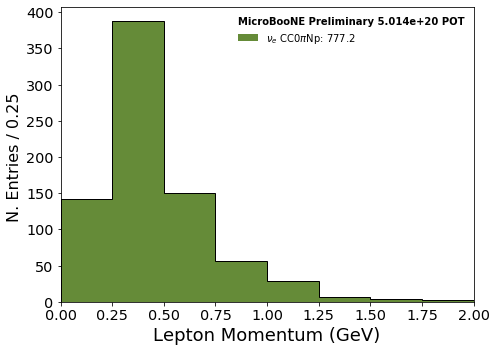

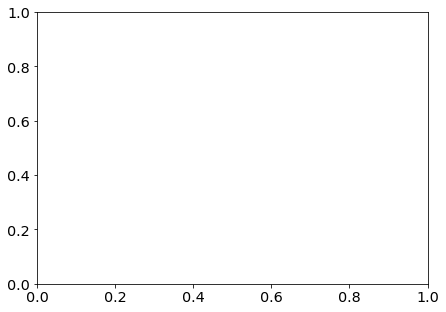

In [28]:
#TRUTH

import batch_plotter_alex
import importlib
importlib.reload(batch_plotter_alex)
scaling = 1

SPLIT = 1.0

n_events = numu_mc.shape[0]
print("n_events here = ", n_events)
print("")
batch_size = n_events

varss1 = []
weightss1 = []
labss1 = []


for i in range(int(n_events/batch_size)+1):
    start = i*batch_size
    if (start + batch_size) < n_events:
        end = start + batch_size
    else:
        end = n_events
    sample_set = numu_mc.iloc[start:end]

    samples = {
        "numu_mc": sample_set 
    }


    scaling = 1
    if isRun3 == False:
        pot =  2e+20 
        mcratio   = pot/2.33978e+21
    elif isRun3 == True:
        pot =  5.014e20
        mcratio  = pot/2.64408e+21


    weights = {
                "numu_mc"  : mcratio  * SPLIT * scaling
    }


    my_plotter = batch_plotter_alex.Plotter(samples, weights, pot=pot)
    
    VARIABLE, BINS, RANGE, XTIT = 'targetP',8,(0.0, 2.0),"Lepton Momentum (GeV)"
    
    

    var, weight, label = my_plotter.plot_variable(
        VARIABLE,
        query= SIGNAL_NUMU_SEL_QUERY,
        currentsample = "numu_mc",
        kind="event_category",
        draw_sys  = True, 
        draw_geoSys = True, 
        draw_data = True,
        ratio=False,
        genieweight = "weightSplineTimesTuneTimesPPFX",  
        stacksort=3,
        title=XTIT,
        bins=BINS,
        range=RANGE
    )[0:3]
    
    varss1.append(var)
    weightss1.append(weight)
    labss1.append(label)

No handles with labels found to put in legend.


(array([141.39273606, 387.42289104, 149.98675866,  56.38378902,
        28.67028598,   7.0597958 ,   3.6145951 ,   2.68122461]), array([0.  , 0.25, 0.5 , 0.75, 1.  , 1.25, 1.5 , 1.75, 2.  ]), <a list of 8 Patch objects>)
(array([0., 0., 0., 0., 0., 0., 0., 0.]), array([0.  , 0.25, 0.5 , 0.75, 1.  , 1.25, 1.5 , 1.75, 2.  ]), <a list of 8 Patch objects>)


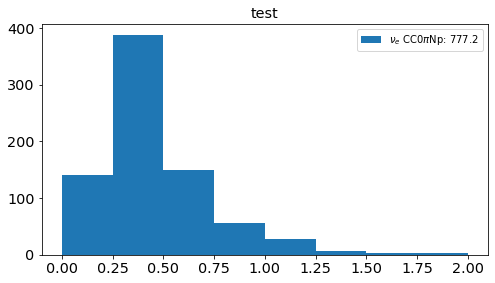

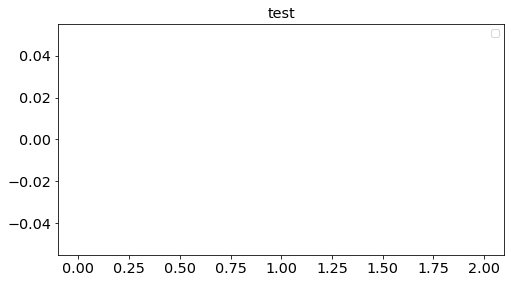

In [29]:
from matplotlib import gridspec

for i in range(int(n_events/batch_size)+1):
    numu_fig = plt.figure(figsize=(8, 7))
    numu_gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1])
    numu_ax1 = plt.subplot(numu_gs[0])

    numu_stacked = numu_ax1.hist(
                varss1[i].values(),
                weights=list(weightss1[i].values()),
                stacked=True,
                label=labss1[i],
                bins=BINS,
                range=RANGE)
    
    plt.title("test")
    plt.legend()
    
    print(numu_stacked)

[141.39273606 387.42289104 149.98675866  56.38378902  28.67028598
   7.0597958    3.6145951    2.68122461]


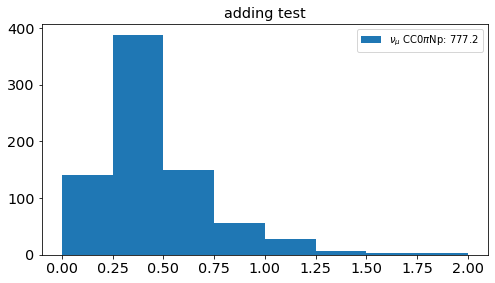

In [30]:
def mergeDictionary(dict_1, dict_2):
    dict_3 = {**dict_1, **dict_2}
    for key, value in dict_3.items():
        if key in dict_1 and key in dict_2:
                dict_3[key] = value + dict_1[key]
    return dict_3

def combine_dicts(mydict):
    while len(mydict) > 1:
        i = 0
        dict_3 = mergeDictionary(mydict[i], mydict[i+1]) 
        mydict.pop(0)
        mydict[0] = dict_3
    return mydict
    
varss_tot = combine_dicts(varss1)
weightss_tot = combine_dicts(weightss1)

category_labels = {
    1 : r'$\nu_\mu$ CC0$\pi$Np', 
    2 : r'Out FV',
    3 : r'$\nu_e$ CC $\pi^{0}$',
    4 : r'$\nu_e$ CC',
    5 : r'$\nu_e$ NC $\pi^{0}$',
    6 : r'$\nu_e$ NC',
    7 : r'$\bar{\nu}_\mu$ CC0$\pi$Np',
    8: r'$\nu_\mu$ NC',
    9: r'$\nu_\mu$ CC other',
    10 : r'$\nu_\mu$ / $\overline{\nu_\mu}$  other', 
    11 : r'$\nu_\mu$ / $\overline{\nu_e}$  $\pi^{0}$', 
    12 : r'$\nu_\mu$ / $\overline{\nu_e}$  other',
    0: r'Unknown'
}


labels = [
            "%s: %.1f" % (category_labels[c], sum(weightss_tot[0][c])) \
            if sum(weightss_tot[0][c]) else ""
            for c in varss1[0].keys()
        ]


numu_fig = plt.figure(figsize=(8, 7))
numu_gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1])
numu_ax1 = plt.subplot(numu_gs[0])

numu_stacked = numu_ax1.hist(
            varss_tot[0].values(),
            weights=list(weightss_tot[0].values()),
            stacked=True,
            label=labels,
            bins=BINS,
            range=RANGE)

plt.title("adding test")
plt.legend()

print(numu_stacked[0])

temp_truth_sig = numu_stacked[0]

n_events here =  65866

1.0
1
{'numu_mc': 0.1896311760612387}
nslice == 1 and ( (_opfilter_pe_beam > 0 and _opfilter_pe_veto < 20) or bnbdata == 1 or extdata == 1) and reco_nu_vtx_sce_x > 15 and reco_nu_vtx_sce_x < 245 and reco_nu_vtx_sce_y > -105 and reco_nu_vtx_sce_y < 105 and reco_nu_vtx_sce_z > 10 and reco_nu_vtx_sce_z < 990 and n_muons_tot > 0 and n_protons_tot > 0 and n_showers_contained==0 and contained_fraction> 0.95 and topological_score > 0.3and is_signal==True& muon_mom <= 2 & muon_mom >= 0 
 ~(abs(nu_pdg)==12 and ccnc==0 and -1.55<=true_nu_vtx_x<=254.8 and -116.5<=true_nu_vtx_y<=116.5 and 0<=true_nu_vtx_z<=1036.8) 
 None 
 False 
 numu_mc
--------------------------------------
current_total  777.212076261981
777.212076261980996605416294187307357788085937500000000000000000000000000000000
---------------------------STILL TOGETHER HERE--------------------------------
current_total  777.212076261981
777.212076261980996605416294187307357788085937500000000000000000000000000000000

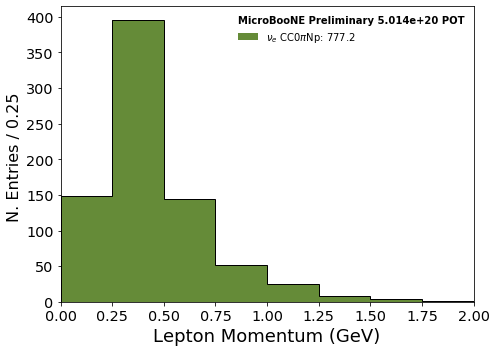

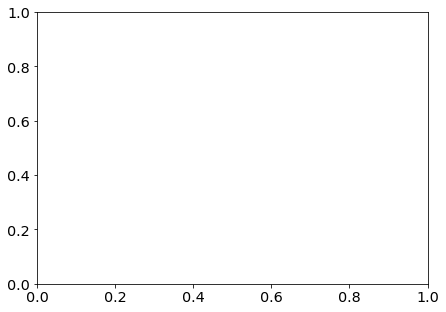

In [31]:
# NOW WITH RECO SELECTION

import batch_plotter_alex
import importlib
importlib.reload(batch_plotter_alex)
scaling = 1

SPLIT = 1.0

n_events = numu_mc.shape[0]
print("n_events here = ", n_events)
print("")
batch_size = n_events

varss2 = []
weightss2 = []
labss2 = []

for i in range(int(n_events/batch_size)+1):
    start = i*batch_size
    if (start + batch_size) < n_events:
        end = start + batch_size
    else:
        end = n_events
    sample_set = numu_mc.iloc[start:end]

    samples = {
        "numu_mc": sample_set 
    }


    scaling = 1
    if isRun3 == False:
        pot =  2e+20 
        mcratio   = pot/2.33978e+21
    elif isRun3 == True:
        pot =  5.014e20
        mcratio  = pot/2.64408e+21

    weights = {
                "numu_mc"  : mcratio  * SPLIT * scaling
    }


    my_plotter = batch_plotter_alex.Plotter(samples, weights, pot=pot)
    
    VARIABLE, BINS, RANGE, XTIT = 'muon_mom',8,(0.0, 2.0),"Lepton Momentum (GeV)"

    

    var, weight, label = my_plotter.plot_variable(
        VARIABLE,
        query= SIGNAL_NUMU_SEL_QUERY,
        currentsample = "numu_mc",
        kind="event_category",
        draw_sys  = True, 
        draw_geoSys = True, 
        draw_data = True,
        ratio=False,
        genieweight = "weightSplineTimesTuneTimesPPFX",  
        stacksort=3,
        title=XTIT,
        bins=BINS,
        range=RANGE
    )[0:3]
    
    varss2.append(var)
    weightss2.append(weight)
    labss2.append(label)

No handles with labels found to put in legend.


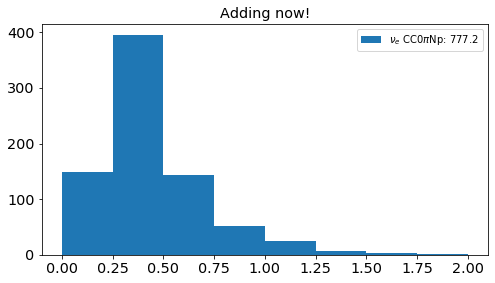

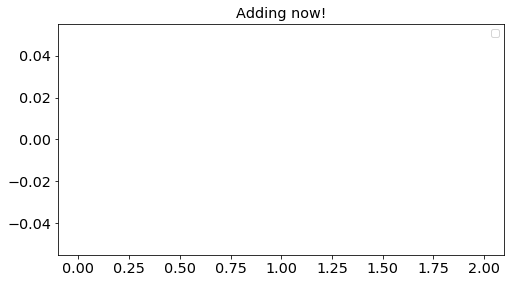

In [32]:
from matplotlib import gridspec

for i in range(int(n_events/batch_size)+1):
    numu_fig = plt.figure(figsize=(8, 7))
    numu_gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1])
    numu_ax1 = plt.subplot(numu_gs[0])

    numu_stacked = numu_ax1.hist(
                varss2[i].values(),
                weights=list(weightss2[i].values()),
                stacked=True,
                label=labss2[i],
                bins=BINS,
                range=RANGE)
    
    plt.title("Adding now!")
    plt.legend()

In [5]:
# plot the smearing matrix 
def plot_smearing(var1, var2, weight1, weight2, var3, weight3, bins, norm=False): 
    fig = plt.figure(figsize=(10, 6))
    
    smear = plt.hist2d(var1, var2,
                   bins, weights=weight1, cmin=0.000000001, cmap='OrRd')
    
    sel1 = plt.hist(var1, bins, weights=weight1, color='white')
    print("sel1 = ", sel1[0])
    print("sum sel1 = ", math.fsum(sel1[0]))
    print("")
    sel2 = plt.hist(var2, bins, weights=weight2, color='white')
    print("sel2 = ", sel2[0])
    print("sum sel2 = ", math.fsum(sel2[0]))
    print("")
    print("truth - reco (sel1 - sel2) ")
    print(sel1[0] - sel2[0])
    print(math.fsum(sel1[0]) - math.fsum(sel2[0]))
    
    zero_copy_smear = np.copy(smear[0].T)
    
    for i in range(len(bins)-1): # reco bins i (y axis) rows
        for j in range(len(bins)-1): # true bins j (x axis) cols
            if np.isnan(zero_copy_smear[i,j]):
                zero_copy_smear[i,j]= 0

    for i in range(len(bins)-1): # reco bins i (y axis) rows
        for j in range(len(bins)-1): # true bins j (x axis) cols
            if smear[0].T[i,j] > 0: 
                if smear[0].T[i,j]>80: 
                    col='white'
                else: 
                    col='black'
                    
                binx_centers = smear[1][j]+(smear[1][j+1]-smear[1][j])/2
                biny_centers = smear[2][i]+(smear[2][i+1]-smear[2][i])/2
                        
                plt.text(binx_centers, biny_centers, round(smear[0].T[i,j], 1), 
                    color=col, ha="center", va="center", fontsize=12)

    cbar = plt.colorbar()
    cbar.set_label('Selected Signal Events', fontsize=15)
        
    print("---------------------------------------------------------")

    if norm: 
        plt.close()
        
        norm_array = smear[0].T
        
        gen = plt.hist(var3, bins, weights=weight3, color='deepskyblue')
        print("")
        print("GENERATED")
        print(gen[0])
        print("")
        plt.close()
    
        # for each truth bin (column): 
        for j in range(len(bins)-1): 
            # replace with normalized value 
            for i in range(len(bins)-1):
                norm_array[i][j] =  norm_array[i][j] / gen[0][j]
    
        # now plot
        fig = plt.figure(figsize=(10, 6))
        plt.pcolor(bins, bins, norm_array, cmap='OrRd', vmax=1)
        
        zero_copy_smear_norm = np.copy(norm_array)

        for i in range(len(bins)-1): # reco bins i (y axis) rows
            for j in range(len(bins)-1): # true bins j (x axis) cols
                if np.isnan(zero_copy_smear_norm[i,j]):
                    zero_copy_smear_norm[i,j]= 0

        # Loop over data dimensions and create text annotations.
        for i in range(len(bins)-1): # reco bins (rows)
            for j in range(len(bins)-1): # truth bins (cols)
                if norm_array[i][j]>0: 
                
                    if norm_array[i][j]>0.7: 
                        col = 'white'
                    else: 
                        col = 'black'
                    
                    binx_centers = smear[1][j]+(smear[1][j+1]-smear[1][j])/2
                    biny_centers = smear[2][i]+(smear[2][i+1]-smear[2][i])/2
                
                    plt.text(binx_centers, biny_centers, round(norm_array[i][j], 2), 
                         ha="center", va="center", color=col, fontsize=12)
      
        cbar = plt.colorbar()
        cbar.set_label('Fraction of Reco Events in True Bin', fontsize=15)
        
        
        if isRun3 == False and isCombined == False:
            #WHOOPS, overwrote 3dp if needed again....
            np.savetxt("numu_full_500_catsel_nopions_leptonMom_usingSelection_smearcept_weighted_recoCut_"+ending+".csv", 
                zero_copy_smear_norm,
                delimiter =", ", 
                fmt ='% s')

            print("ZERO COPY SMEAR NORM")
            print(zero_copy_smear_norm)

        elif isRun3 == True and isCombined == False:
            np.savetxt("numu_full_500_catsel_nopions_leptonMom_usingSelection_smearcept_weighted_recoCut_run3_"+ending+".csv", 
                zero_copy_smear_norm,
                delimiter =", ", 
                fmt ='% s')

            print("ZERO COPY SMEAR NORM")
            print(zero_copy_smear_norm)

    
        elif isCombined == True:
            print("Saving!")
            np.savetxt("numu_full_500_catsel_nopions_leptonMom_usingSelection_smearcept_weighted_recoCut_comb_"+ending+".csv", 
                zero_copy_smear_norm,
                delimiter =", ", 
                fmt ='% s')

            print("ZERO COPY SMEAR NORM")
            print(zero_copy_smear_norm)

    plt.xlabel('True ν Energy [GeV]', fontsize=15)
    plt.ylabel('Reco ν Energy [GeV]', fontsize=15)
    plt.text(0.1, 1.8, r'MicroBooNE In Progress', fontweight='bold')
    
    plt.show()
    fig.savefig("numu_full_500_catsel_nopions_leptonMom_usingSelection_smearcept_weighted_recoCut_comb_"+ending+".svg",bbox_inches='tight' )
    
    if norm:
        return zero_copy_smear_norm
    else:
        return zero_copy_smear

In [6]:
def _selection(variable, sample, query="selected==1", extra_cut=None, track_cuts=None, select_longest=True):
        '''
        variable,  must be specified
        select_longest, True by default, keeps from multiple tracks of same event making it through
        query must be a string defining event-level cuts
        track_cuts is a list of cuts of which each entry looks like
            (variable_tobe_cut_on, '>'or'<'or'=='etc, cut value )
            or
            (variable, [operator1, operator2], [cutval1, cutval2]) to do an 'or' cut
        track_
        returns an Series of values that pass all track_cuts
        '''
        sel_query = query
        if extra_cut is not None:
            sel_query += "& %s" % extra_cut

        df = sample.query(sel_query)

        track_cuts_mask = None #df['trk_score_v'].apply(lambda x: x == x) #all-True mask, assuming trk_score_v is available
        if track_cuts is not None:
            vars, track_cuts_mask = _apply_track_cuts(df,variable,track_cuts,track_cuts_mask)
        else:
            vars = df[variable]
        #vars is now a Series object that passes all the cuts
        #select longest of the cut passing tracks
        #assuming all track-level variables end in _v
        if variable[-2:] == "_v" and select_longest:
            vars, longest_mask = _select_longest(df, vars, track_cuts_mask)
        elif "_v_" in variable:
            print("Variable is being interpretted as event-level, not track_level, despite having _v in name")
            print("the longest track is NOT being selected")
        return vars.ravel()
    
#-------------------------------------------------------------------
def _apply_track_cuts(df,variable,track_cuts,mask):
    '''
    df is dataframe of the sample of interest
    variable is what values will be in the output
    track_cuts are list of tuples defining track_cuts
    input mask to be built upon

    returns
        Series of values of variable that pass all track_cuts
        boolean mask that represents union of input mask and new cut mask
    '''
    #need to do this fancy business with the apply function to make masks
    #this is because unflattened DataFrames are used
    for (var,op,val) in track_cuts:
        if type(op) == list:
            #this means treat two conditions in an 'or' fashion
            or_mask1 = df[var].apply(lambda x: eval("x{}{}".format(op[0],val[0])))#or condition 1
            or_mask2 = df[var].apply(lambda x: eval("x{}{}".format(op[1],val[1])))#or condition 2
            mask *= (or_mask1 + or_mask2) #just add the booleans for "or"
        else:
            mask *= df[var].apply(lambda x: eval("x{}{}".format(op,val))) #layer on each cut mask
    vars = (df[variable]*mask).apply(lambda x: x[x != False]) #apply mask
    vars = vars[vars.apply(lambda x: len(x) > 0)] #clean up empty slices
    #fix list comprehension issue for non '_v' variables
    if variable[-2:] != "_v":
        vars = vars.apply(lambda x: x[0])
    elif "_v" not in variable:
        print("_v not found in variable, assuming event-level")
        print("not fixing list comprehension bug for this variable")

    return vars, mask
    
#-----------------------------------------------------------------------

def _select_longest(df, variable, mask):
    '''
    df: dataframe for sample
    variable: Series of values that pass cuts defined by mask
    mask: mask used to find variable

    returns
        list of values of variable corresponding to longest track in each slices
        boolean mask for longest tracks in df
    '''
    trk_lens = (df['trk_len_v']*mask).apply(lambda x: x[x != False])#apply mask to track lengths
    trk_lens = trk_lens[trk_lens.apply(lambda x: len(x) > 0)]#clean up slices
    variable = variable.apply(lambda x: x[~np.isnan(x)])#clean up nan vals
    variable = variable[variable.apply(lambda x: len(x) > 0)] #clean up empty slices
    nan_mask = variable.apply(lambda x: np.nan in x or "nan" in x)
    longest_mask = trk_lens.apply(lambda x: x == x[list(x).index(max(x))])#identify longest
    variable = (variable*longest_mask).apply(lambda x: x[x!=False])#apply mask
    if len(variable.iloc[0]) == 1:
        variable = variable.apply(lambda x: x[0] if len(x)>0 else -999)#expect values, not lists, for each event
    else:
        if len(variable.iloc[0]) == 0:
            raise ValueError(
                "There is no longest track per slice")
        elif len(variable.iloc[0]) > 1:
            #this happens with the reco_nu_e_range_v with unreconstructed values
            print("there are more than one longest slice")
            print(variable.iloc[0])
            try:
                variable = variable.apply(lambda x: x[0])
            except:
                raise ValueError(
                    "There is more than one longest track per slice in \n var {} lens {}".format(variable,trk_lens))

    return variable, longest_mask
    
#-----------------------------------------------------------------------
def _get_genie_weight(sample, variable, query="selected==1", extra_cut=None, track_cuts=None,\
                          select_longest=True, weightvar="weightSplineTimesTuneTimesPPFX",weightsignal=None):

        plotted_variable = _selection(
            variable, sample, query=query, extra_cut=extra_cut, track_cuts=track_cuts, select_longest=select_longest)
        genie_weights = _selection(
            weightvar, sample, query=query, extra_cut=extra_cut, track_cuts=track_cuts, select_longest=select_longest)
        if (weightsignal != None):
            genie_weights *= _selection(
            weightsignal, sample, query=query, extra_cut=extra_cut, track_cuts=track_cuts, select_longest=select_longest)
        if plotted_variable.size > 0:
            if isinstance(plotted_variable[0], np.ndarray):
                if "trk" in variable or select_longest:
                    score = self._selection(
                        "trk_score_v", sample, query=query, extra_cut=extra_cut, track_cuts=track_cuts, select_longest=select_longest)
                else:
                    score = self._selection(
                        "shr_score_v", sample, query=query, extra_cut=extra_cut, track_cuts=track_cuts, select_longest=select_longest)
                genie_weights = np.array([
                    np.array([c] * len(v[s > 0.5])) for c, v, s in zip(genie_weights, plotted_variable, score)
                ])
                genie_weights = np.hstack(genie_weights)
        return genie_weights

n_events here =  65866
n_events/2 here =  32933.0

1.0
1
All is well.
sel1 =  [141.39274597 387.4230957  149.98693848  56.3838501   28.67041016
   7.05963135   3.61456299   2.68127441]
sum sel1 =  777.2125091552734

sel2 =  [148.06349182 394.77490234 144.12969971  52.2276001   25.33575439
   7.44573975   3.79351807   1.44207764]
sum sel2 =  777.2127838134766

truth - reco (sel1 - sel2) 
[-6.67074585 -7.35180664  5.85723877  4.15625     3.33465576 -0.3861084
 -0.17895508  1.23919678]
-0.000274658203125
---------------------------------------------------------

GENERATED
[2120.49780273 3633.37329102 2422.54980469 1582.54980469 1069.67871094
  728.08398438  512.18554688 1818.11132812]

ZERO COPY SMEAR NORM
[[6.10893351e-02 4.32243065e-03 5.24460981e-04 7.52782162e-04
  1.88522177e-04 0.00000000e+00 0.00000000e+00 8.53236190e-05]
 [5.49695214e-03 1.00627689e-01 5.55742509e-03 1.02321200e-03
  1.22767423e-03 3.09754147e-04 0.00000000e+00 4.83596081e-04]
 [0.00000000e+00 1.67886320e-03 5.466

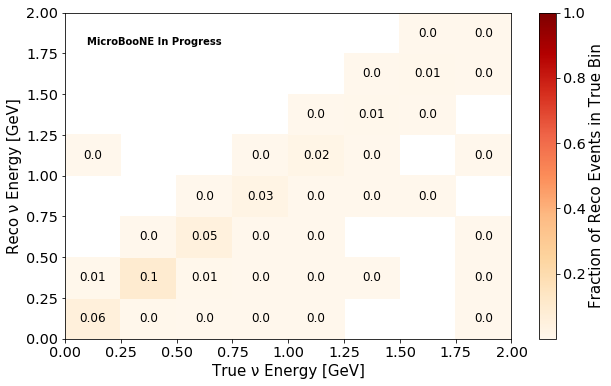

In [35]:
n_events = numu_mc.shape[0]
print("n_events here = ", n_events)
print("n_events/2 here = ", np.floor(n_events/2))
print("")
batch_size = n_events

varss = []
weightss = []
labss = []

start = 0*batch_size
if (start + batch_size) < n_events:
    end = start + batch_size
else:
    end = n_events
sample_set = numu_mc.iloc[start:end]


scaling = 1
if isRun3 == False:
    pot =  2e+20 
    mcratio   = pot/2.33978e+21
elif isRun3 == True:
    pot =  5.014e20
    mcratio  = pot/2.64408e+21

weights = {
            "numu_mc"  : mcratio  * SPLIT * scaling
}

current_genie_weights = _get_genie_weight(
                sample_set, 'targetP', query=SIGNAL_NUMU_SEL_QUERY, track_cuts=None,select_longest=False, weightvar="weightSplineTimesTuneTimesPPFX")


current_genie_weights2 = _get_genie_weight(
                sample_set, 'muon_mom', query=SIGNAL_NUMU_SEL_QUERY, track_cuts=None,select_longest=False, weightvar="weightSplineTimesTuneTimesPPFX")


current_genie_weights3 = _get_genie_weight(
                sample_set, 'targetP', query=SIGNAL_ONLY_NUMU_SEL_QUERY, track_cuts=None,select_longest=False, weightvar="weightSplineTimesTuneTimesPPFX")

test_list1 = current_genie_weights
test_list2 = current_genie_weights2

if len(test_list1) == len(test_list2) and len(test_list1) == sum([1 for i, j in zip(test_list1, test_list2) if i == j]):
    print("All is well.")
else:
    print("Oh no.")

bins = np.arange(0.0, 2.25, 0.25)  


var1 = sample_set.query(SIGNAL_NUMU_SEL_QUERY)['targetP']
weight1 = current_genie_weights * weights["numu_mc"]
if isRun3 == False and isCombined == False:
    var1.to_csv("numu_full_var1_recoCut_leptonMom_"+ending+".csv")
    np.savetxt("numu_full_weight1_recoCut_leptonMom_"+ending+".csv", 
                weight1,
                delimiter =", ", 
                fmt ='% s')
if isRun3 == True and isCombined == False:
    var1.to_csv("numu_full_var1_recoCut_run3_leptonMom_"+ending+".csv")
    np.savetxt("numu_full_weights1_recoCut_run3_leptonMom_"+ending+".csv", 
                weight1,
                delimiter =", ", 
                fmt ='% s')     

var2 = sample_set.query(SIGNAL_NUMU_SEL_QUERY)['muon_mom']
weight2 = current_genie_weights2* weights["numu_mc"]
if isRun3 == False and isCombined == False:
    var2.to_csv("numu_full_var2_recoCut_leptonMom_"+ending+".csv")
    np.savetxt("numu_full_weight2_recoCut_leptonMom_"+ending+".csv", 
                weight2,
                delimiter =", ", 
                fmt ='% s')
if isRun3 == True and isCombined == False:
    var2.to_csv("numu_full_var2_recoCut_run3_leptonMom_"+ending+".csv")
    np.savetxt("numu_full_weights2_recoCut_run3_leptonMom_"+ending+".csv", 
                weight2,
                delimiter =", ", 
                fmt ='% s')

var3 = sample_set.query(SIGNAL_ONLY_NUMU_SEL_QUERY)['targetP']
weight3 = current_genie_weights3* weights["numu_mc"]
if isRun3 == False and isCombined == False:
    var3.to_csv("numu_full_var3_recoCut_leptonMom_"+ending+".csv")
    np.savetxt("numu_full_weight3_recoCut_leptonMom_"+ending+".csv", 
                weight3,
                delimiter =", ", 
                fmt ='% s')
if isRun3 == True and isCombined == False:
    var3.to_csv("numu_full_var3_recoCut_run3_leptonMom_"+ending+".csv")
    np.savetxt("numu_full_weights3_recoCut_run3_leptonMom_"+ending+".csv", 
                weight3,
                delimiter =", ", 
                fmt ='% s')


zerocopysmear = plot_smearing(var1, var2, weight1, weight2, var3, weight3, bins, norm=True)

### Now look at Efficiency and Purity

In [7]:
def plot_signal_and_eff(var1, weight1, var2, weight2, bins, variable, xaxis, savetitle, savetitleplot): 
    
    # generated true signal events per bin 
    gen = plt.hist(var1, bins, weights=weight1, color='deepskyblue')
    plt.close()
    
    # plot selected signal events 
    fig, ax1 = plt.subplots(figsize=(4, 5))
    
    # compute efficiency
    sel = ax1.hist(var2, bins, weights=weight2, color='white')
    print("sel = ", sel[0])
    print("")
    print("gen = ", gen[0])
    eff = [ a/b for a, b in zip(sel[0], gen[0]) ]
    eff_err = []
    for i in range(len(eff)):
        eff_err.append(math.sqrt( (eff[i]*(1-eff[i]))/gen[0][i] ) )
        print("In bin", i, ", eff = ", eff[i], " with error = ", eff_err[i])
        
    eff_tot = sum(sel[0])/sum(gen[0])
    print("Total Eff")
    print(eff_tot)
        
    # compute bin centers 
    bc = 0.5*(sel[1][1:]+sel[1][:-1])
    x_err = []
    for i in range(len(sel[1])-1): 
        x_err.append((sel[1][i+1]-sel[1][i])/2)

    # plot efficiency
    ax1.errorbar(bc, eff, xerr=x_err, yerr=eff_err, fmt='o', color='orangered', ecolor='orangered', markersize=3) 
    ax1.set_ylim(0, 1)
    ax1.set_ylabel('Efficiency', fontsize=15)
    ax1.set_title("Efficiency")
    ax1.set_xlabel(xaxis)
    
    np.savetxt(savetitle,
           eff,
           delimiter =", ", 
           fmt ='% s')
    
    print("Plot title: ", savetitleplot)
    fig.savefig(savetitleplot,bbox_inches='tight' )

    plt.show()

In [37]:
bins = np.arange(0, 2.25, 0.25)


scaling = 1
SPLIT = 1.0


if isRun3 == False:
    pot =  2e+20 
    mcratio   = pot/2.33978e+21
elif isRun3 == True:
    pot =  5.014e20
    mcratio  = pot/2.64408e+21

weights = {
            "numu_mc"  : mcratio  * SPLIT * scaling
}

current_genie_weights = _get_genie_weight(
                numu_mc, 'targetP', query=SIGNAL_ONLY_NUMU_SEL_QUERY, track_cuts=None,select_longest=False, weightvar="weightSplineTimesTuneTimesPPFX")

current_genie_weights2 = _get_genie_weight(
                numu_mc, 'targetP', query=SIGNAL_NUMU_SEL_QUERY, track_cuts=None,select_longest=False, weightvar="weightSplineTimesTuneTimesPPFX")


var1 = numu_mc.query(SIGNAL_ONLY_NUMU_SEL_QUERY)['targetP']
weight1 = current_genie_weights* weights["numu_mc"]
if isRun3 == False and isCombined == False:
    var1.to_csv("numu_full_var1_eff_recoCut_leptonMom_"+ending+".csv")
    np.savetxt("numu_full_weight1_eff_recoCut_leptonMom_"+ending+".csv", 
                weight1,
                delimiter =", ", 
                fmt ='% s')
if isRun3 == True and isCombined == False:
    var1.to_csv("numu_full_var1_eff_recoCut_run3_leptonMom_"+ending+".csv")
    np.savetxt("numu_full_weights1_eff_recoCut_run3_leptonMom_"+ending+".csv", 
                weight1,
                delimiter =", ", 
                fmt ='% s') 

var2 = numu_mc.query(SIGNAL_NUMU_SEL_QUERY)['targetP']
weight2 = current_genie_weights2 * weights["numu_mc"]
if isRun3 == False and isCombined == False:
    var2.to_csv("numu_full_var2_eff_recoCut_leptonMom_"+ending+".csv")
    np.savetxt("numu_full_weight2_eff_recoCut_leptonMom_"+ending+".csv", 
                weight2,
                delimiter =", ", 
                fmt ='% s')
if isRun3 == True and isCombined == False:
    var2.to_csv("numu_full_var2_eff_recoCut_run3_leptonMom_"+ending+".csv")
    np.savetxt("numu_full_weights2_eff_recoCut_run3_leptonMom_"+ending+".csv", 
                weight2,
                delimiter =", ", 
                fmt ='% s')

###########################################

variable = 'targetP'
xaxis = "True Lepton Momentum [Gev]"
if isRun3 == False and isCombined == False:
    savetitle = "batch_eff_numu_fig_full_500_catsel_nopions_leptonMom_matrix_trueeff_"+ending+".csv"
if isRun3 == True and isCombined == False:
    savetitle = "batch_eff_numu_fig_full_500_catsel_nopions_leptonMom_matrix_trueeff_run3_"+ending+".csv"

### Combined Loading and Calculation

<class 'pandas.core.series.Series'>
<class 'numpy.ndarray'>
sel1 =  [208.38094403 548.88084295 220.89209575  90.10964838  47.84740223
  14.41378274   4.99233407   2.87145699]
sum sel1 =  1138.3885071427715

sel2 =  [214.81252683 565.99040072 215.99887635  79.89772494  40.51671936
  14.65559086   4.81847401   1.69819407]
sum sel2 =  1138.3885071427721

truth - reco (sel1 - sel2) 
[ -6.4315828  -17.10955777   4.89321941  10.21192344   7.33068287
  -0.24180812   0.17386006   1.17326291]
-6.821210263296962e-13
---------------------------------------------------------

GENERATED
[3281.49932828 5253.67178112 3570.89365707 2525.9601228  1828.4306197
 1264.64171841  833.92544398 2396.84738082]

Saving!
ZERO COPY SMEAR NORM
[[5.81939125e-02 3.92497501e-03 4.48772137e-04 4.71628692e-04
  1.53000615e-04 0.00000000e+00 0.00000000e+00 6.47216178e-05]
 [5.14454388e-03 9.91472846e-02 6.03106735e-03 1.14005396e-03
  1.38423911e-03 3.12376571e-04 0.00000000e+00 3.66828325e-04]
 [5.09043469e-05 1.375788

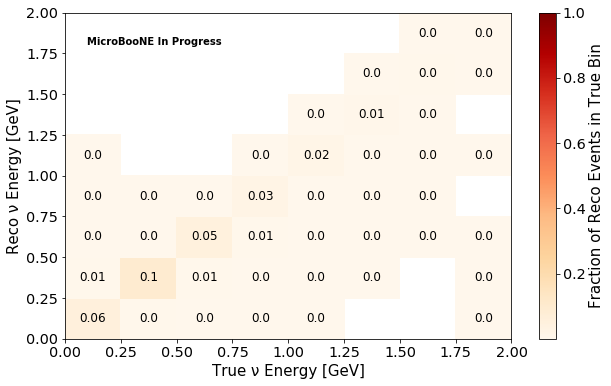

In [8]:
#####Smearing####
smearing_var1_run1 = pd.read_csv("numu_full_var1_recoCut_leptonMom_"+ending+".csv")

with open('numu_full_weight1_recoCut_leptonMom_'+ending+'.csv', 'r') as read_obj:
        csv_reader = csv.reader(read_obj)
        smearing_weight1_run1 = list(csv_reader)

for a in range(len(smearing_weight1_run1)):
    smearing_weight1_run1[a] = float(smearing_weight1_run1[a][0])
### 
smearing_var2_run1 = pd.read_csv("numu_full_var2_recoCut_leptonMom_"+ending+".csv")

with open('numu_full_weight2_recoCut_leptonMom_'+ending+'.csv', 'r') as read_obj:
        csv_reader = csv.reader(read_obj)
        smearing_weight2_run1 = list(csv_reader)

for a in range(len(smearing_weight2_run1)):
    smearing_weight2_run1[a] = float(smearing_weight2_run1[a][0])
### 
smearing_var3_run1 = pd.read_csv("numu_full_var3_recoCut_leptonMom_"+ending+".csv")

with open('numu_full_weight3_recoCut_leptonMom_'+ending+'.csv', 'r') as read_obj:
        csv_reader = csv.reader(read_obj)
        smearing_weight3_run1 = list(csv_reader)

for a in range(len(smearing_weight3_run1)):
    smearing_weight3_run1[a] = float(smearing_weight3_run1[a][0])
###---####
smearing_var1_run3 = pd.read_csv("numu_full_var1_recoCut_run3_leptonMom_"+ending+".csv")

with open('numu_full_weights1_recoCut_run3_leptonMom_'+ending+'.csv', 'r') as read_obj:
        csv_reader = csv.reader(read_obj)
        smearing_weight1_run3 = list(csv_reader)

for a in range(len(smearing_weight1_run3)):
    smearing_weight1_run3[a] = float(smearing_weight1_run3[a][0])
### 
smearing_var2_run3 = pd.read_csv("numu_full_var2_recoCut_run3_leptonMom_"+ending+".csv")

with open('numu_full_weights2_recoCut_run3_leptonMom_'+ending+'.csv', 'r') as read_obj:
        csv_reader = csv.reader(read_obj)
        smearing_weight2_run3 = list(csv_reader)

for a in range(len(smearing_weight2_run3)):
    smearing_weight2_run3[a] = float(smearing_weight2_run3[a][0])
### 
smearing_var3_run3 = pd.read_csv("numu_full_var3_recoCut_run3_leptonMom_"+ending+".csv")

with open('numu_full_weights3_recoCut_run3_leptonMom_'+ending+'.csv', 'r') as read_obj:
        csv_reader = csv.reader(read_obj)
        smearing_weight3_run3 = list(csv_reader)

for a in range(len(smearing_weight3_run3)):
    smearing_weight3_run3[a] = float(smearing_weight3_run3[a][0])
    
####################Add#####################

var_temps = [smearing_var1_run1, smearing_var1_run3]
var1 = pd.concat(var_temps)
var1 = var1.drop(["entry"], axis=1)
var1 = var1.squeeze()
weight1 = list(smearing_weight1_run1) + list(smearing_weight1_run3)
weight1 = np.array(weight1)

var_temps = [smearing_var2_run1, smearing_var2_run3]
var2 = pd.concat(var_temps)
var2 = var2.drop(["entry"], axis=1)
var2 = var2.squeeze()
weight2 = list(smearing_weight2_run1) + list(smearing_weight2_run3)
weight2 = np.array(weight2)

var_temps = [smearing_var3_run1, smearing_var3_run3]
var3 = pd.concat(var_temps)
var3 = var3.drop(["entry"], axis=1)
var3 = var3.squeeze()
weight3 = list(smearing_weight3_run1) + list(smearing_weight3_run3)
weight3 = np.array(weight3)

bins = np.arange(0, 2.25, 0.25)

zerocopysmear = plot_smearing(var1, var2, weight1, weight2, var3, weight3, bins, norm=True)

<class 'pandas.core.series.Series'>
<class 'numpy.ndarray'>
sel =  [208.38094403 548.88084295 220.89209575  90.10964838  47.84740223
  14.41378274   4.99233407   2.87145699]

gen =  [3281.49932828 5253.67178112 3570.89365707 2525.9601228  1828.4306197
 1264.64171841  833.92544398 2396.84738082]
In bin 0 , eff =  0.06350174819128633  with error =  0.004257063873224199
In bin 1 , eff =  0.10447566308264927  with error =  0.004220022786061145
In bin 2 , eff =  0.06185905181359297  with error =  0.004031319480859426
In bin 3 , eff =  0.035673424757739845  with error =  0.0036903811654660345
In bin 4 , eff =  0.026168563202174845  with error =  0.0037332974301994737
In bin 5 , eff =  0.011397522735752228  with error =  0.00298491747547696
In bin 6 , eff =  0.005986547241044919  with error =  0.0026712880762362013
In bin 7 , eff =  0.0011980141115748627  with error =  0.000706562322336842
Total Eff
0.05432313257850065
Plot title:  batch_eff_numu_fig_full_500_catsel_nopions_leptonMom_matrix_t

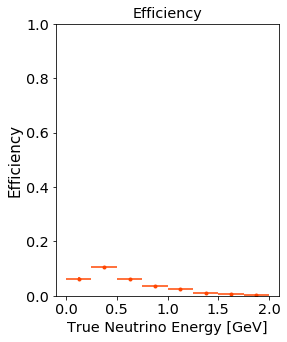

In [9]:

#####Efficiency####
smearing_var1_run1 = pd.read_csv("numu_full_var1_eff_recoCut_leptonMom_"+ending+".csv")

with open('numu_full_weight1_eff_recoCut_leptonMom_'+ending+'.csv', 'r') as read_obj:
        csv_reader = csv.reader(read_obj)
        smearing_weight1_run1 = list(csv_reader)

for a in range(len(smearing_weight1_run1)):
    smearing_weight1_run1[a] = float(smearing_weight1_run1[a][0])
### 
smearing_var2_run1 = pd.read_csv("numu_full_var2_eff_recoCut_leptonMom_"+ending+".csv")

with open('numu_full_weight2_eff_recoCut_leptonMom_'+ending+'.csv', 'r') as read_obj:
        csv_reader = csv.reader(read_obj)
        smearing_weight2_run1 = list(csv_reader)

for a in range(len(smearing_weight2_run1)):
    smearing_weight2_run1[a] = float(smearing_weight2_run1[a][0])
###---####
smearing_var1_run3 = pd.read_csv("numu_full_var1_eff_recoCut_run3_leptonMom_"+ending+".csv")

with open('numu_full_weights1_eff_recoCut_run3_leptonMom_'+ending+'.csv', 'r') as read_obj:
        csv_reader = csv.reader(read_obj)
        smearing_weight1_run3 = list(csv_reader)

for a in range(len(smearing_weight1_run3)):
    smearing_weight1_run3[a] = float(smearing_weight1_run3[a][0])
### 
smearing_var2_run3 = pd.read_csv("numu_full_var2_eff_recoCut_run3_leptonMom_"+ending+".csv")

with open('numu_full_weights2_eff_recoCut_run3_leptonMom_'+ending+'.csv', 'r') as read_obj:
        csv_reader = csv.reader(read_obj)
        smearing_weight2_run3 = list(csv_reader)

for a in range(len(smearing_weight2_run3)):
    smearing_weight2_run3[a] = float(smearing_weight2_run3[a][0])
    
####################Add#####################

var_temps = [smearing_var1_run1, smearing_var1_run3]
var1 = pd.concat(var_temps)
var1 = var1.drop(["entry"], axis=1)
var1 = var1.squeeze()
weight1 = list(smearing_weight1_run1) + list(smearing_weight1_run3)
weight1 = np.array(weight1)

var_temps = [smearing_var2_run1, smearing_var2_run3]
var2 = pd.concat(var_temps)
var2 = var2.drop(["entry"], axis=1)
var2 = var2.squeeze()
weight2 = list(smearing_weight2_run1) + list(smearing_weight2_run3)
weight2 = np.array(weight2)


variable = 'true_e'
xaxis = "True Neutrino Energy [GeV]"
isCombined = True
if isCombined == True:
    savetitle = "batch_eff_numu_fig_full_500_catsel_nopions_leptonMom_matrix_trueeff_comb_"+ending+".csv"
    savetitleplot = "batch_eff_numu_fig_full_500_catsel_nopions_leptonMom_matrix_trueeff_"+ending+".svg"

plot_signal_and_eff(var1, weight1, var2, weight2, bins, variable, xaxis, savetitle, savetitleplot)

In [1]:
##########################################################